# Multivariable models

In this notebook I make 4 new models for all characteristics (temperature, humidity, gas, pressure).
These models predict 30 minutes ahead and 1 hour ahead.

Import libraries

In [173]:
import sqlite3
from sklearn.linear_model import LinearRegression
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import seaborn as sns

# Load data set

This data set has information about temperature, humidity, gas, pressure in my room. Every line in my data set have intervale 30 minutes.

In [174]:
conn = sqlite3.connect('climate_data.db')
# Read all data from the 'sensor_logs' table into a Pandas DataFrame
df = pd.read_sql_query("SELECT * FROM sensor_logs", conn)
conn.close()

Check the data

In [175]:
df.head()

,id,timestamp,year,month,day,hour,minute,second,temp,hum,press,gas,alt
0,1,2026-04-25 19:17:49,2026,4,25,19,17,49,24.42,38.88,919.86,4.24,807.01
1,2,2026-04-25 19:47:51,2026,4,25,19,47,51,24.22,39.11,920.47,4.18,801.52
2,3,2026-04-25 20:17:52,2026,4,25,20,17,52,24.05,44.37,920.98,4.16,797.21
3,4,2026-04-25 20:47:53,2026,4,25,20,47,53,24.04,45.80,921.49,4.19,792.53
4,5,2026-04-25 21:17:54,2026,4,25,21,17,54,24.06,47.38,921.93,4.25,788.84


# Data Preprocessing and Feature Engineering


### Timestamp Conversion
- The `timestamp` column is converted from milliseconds to datetime objects.
- The data is resampled to a 30-minute frequency. Missing values introduced by resampling are filled using time-based interpolation.

In [176]:
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
df.set_index('timestamp', inplace=True)
df = df.resample('30min').interpolate(method='time')

# Create new columns

### Cyclical Features for Time
To account for the cyclical nature of hours (e.g., 23:00 is closer to 00:00 than 12:00), sine and cosine transformations are applied to the 'hour' feature.
$$ \text{hour\_sin} = \sin\left(\frac{2 \pi \cdot \text{hour}}{24}\right) $$
$$ \text{hour\_cos} = \cos\left(\frac{2 \pi \cdot \text{hour}}{24}\right) $$

In [177]:
df["hour_sin"] = np.sin(2 * np.pi * df.index.hour / 24)
df["hour_cos"] = np.cos(2 * np.pi * df.index.hour / 24)

## Lagged Features
Previous temperature readings are included as features to capture temporal dependencies.
$$ \text{temp\_lag\_n} = \text{temp}_{t-n} $$
where $t$ is the current timestamp and $n$ is the lag period (e.g., 1, 2, 48 for 30-minute intervals).

### Temperature

In [178]:
# Temperature from the previous 30-minute interval
df['temp_lag_1'] = df['temp'].shift(1)
# Temperature from two previous 30-minute intervals
df['temp_lag_2'] = df['temp'].shift(2)
# Temperature from 48 previous 30-minute intervals (24 hours ago, as 48 * 30min = 24 hours)
df['temp_lag_48'] = df['temp'].shift(48)

df['target_temp_30m'] = df['temp'].shift(-1)
df['target_temp_60m'] = df['temp'].shift(-2)

### Humidity

In [179]:
df["hum_lag_1"] = df["hum"].shift(1)
df["hum_lag_2"] = df["hum"].shift(2)
df["hum_lag_48"] = df["hum"].shift(48)

df['target_hum_30m'] = df['hum'].shift(-1)
df['target_hum_60m'] = df['hum'].shift(-2)

### Gas

In [180]:
df["gas_lag_1"] = df["gas"].shift(1)
df["gas_lag_2"] = df["gas"].shift(2)
df["gas_lag_48"] = df["gas"].shift(48)

df['target_gas_30m'] = df['gas'].shift(-1)
df['target_gas_60m'] = df['gas'].shift(-2)

### Press


In [181]:
df["press_lag_1"] = df["press"].shift(1)
df["press_lag_2"] = df["press"].shift(2)
df["press_lag_48"] = df["press"].shift(48)

df['target_press_30m'] = df['press'].shift(-1)
df['target_press_60m'] = df['press'].shift(-2)

In [182]:
# Remove any rows that still contain NaN values after feature engineering and resampling
df = df.dropna()
# Display information about the DataFrame, including data types and non-null values
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 3599 entries, 2026-04-26 19:30:00 to 2026-07-10 18:30:00
Freq: 30min
Data columns (total 34 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                3599 non-null   float64
 1   year              3599 non-null   float64
 2   month             3599 non-null   float64
 3   day               3599 non-null   float64
 4   hour              3599 non-null   float64
 5   minute            3599 non-null   float64
 6   second            3599 non-null   float64
 7   temp              3599 non-null   float64
 8   hum               3599 non-null   float64
 9   press             3599 non-null   float64
 10  gas               3599 non-null   float64
 11  alt               3599 non-null   float64
 12  hour_sin          3599 non-null   float64
 13  hour_cos          3599 non-null   float64
 14  temp_lag_1        3599 non-null   float64
 15  temp_lag_2        3599 non-null   float64
 16  temp_

In [183]:
# Define columns to be dropped as they are either redundant or not useful for the model
columns_to_drop = ['temp', 'hum', 'press', 'gas', 'hour', 'alt',
    'target_temp_30m', 'target_temp_60m',
    'target_hum_30m', 'target_hum_60m',
    'target_press_30m', 'target_press_60m',
    'target_gas_30m', 'target_gas_60m']
# Drop the specified columns from the DataFrame
X = df.drop(columns_to_drop, axis=1)

# Define Features (X) and Target (y)

In [184]:
y_temp = df[['target_temp_30m', 'target_temp_60m']]
y_hum = df[['target_hum_30m', 'target_hum_60m']]
y_press = df[['target_press_30m', 'target_press_60m']]
y_gas = df[['target_gas_30m', 'target_gas_60m']]

# Data Splitting (80% Train, 20% Test)


In [185]:
split_index = int(len(df)*0.8)

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]

# Function for training

In [186]:
def train_function(y, name):
    y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

    model = LinearRegression()
    model.fit(X_train, y_train)
    prediction = model.predict(X_test)

    # prediction тепер містить дві колонки (прогноз на 30хв і 60хв)
    mae_30m = mean_absolute_error(y_test.iloc[:, 0], prediction[:, 0])
    mae_60m = mean_absolute_error(y_test.iloc[:, 1], prediction[:, 1])

    print(f"--- Результати для {name} ---")
    print(f"MAE (+30 хв): {mae_30m:.4f}")
    print(f"MAE (+60 хв): {mae_60m:.4f}\n")

    plt.figure(figsize=(15, 5))
    # Plot the actual temperature values from the test set
    plt.plot(y_test.index, y_test.values, label=f'{name}', color='coral')
    # Plot the predicted temperature values from the model
    plt.plot(y_test.index, prediction, label='Прогноз (Лінійна Регресія)', color='blue', linestyle='--')
    plt.title('Реальність vs Прогноз (на тестовій вибірці)')
    plt.legend()
    plt.show()

    return model

--- Результати для Temperature ---
MAE (+30 хв): 0.1209
MAE (+60 хв): 0.1902



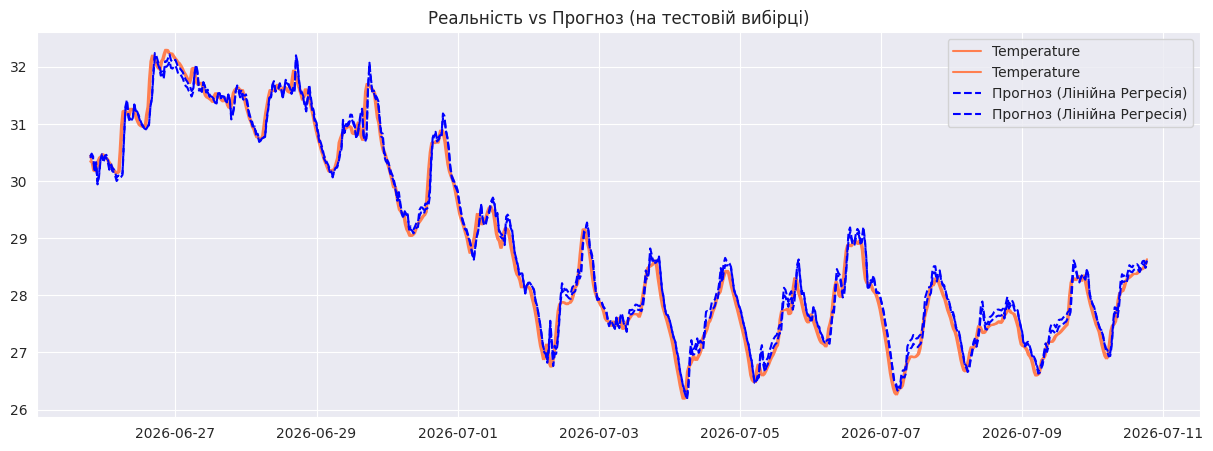

In [187]:
model_temp = train_function(y_temp, "Temperature")

--- Результати для Humidity ---
MAE (+30 хв): 1.1063
MAE (+60 хв): 1.5110



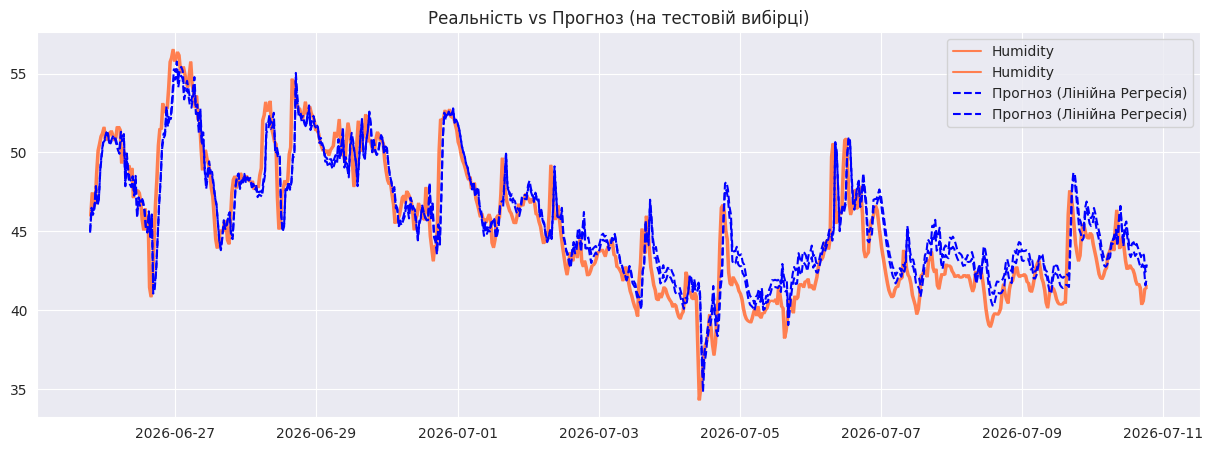

In [188]:
model_hum = train_function(y_hum, "Humidity")

--- Результати для Pressure ---
MAE (+30 хв): 0.1591
MAE (+60 хв): 0.2775



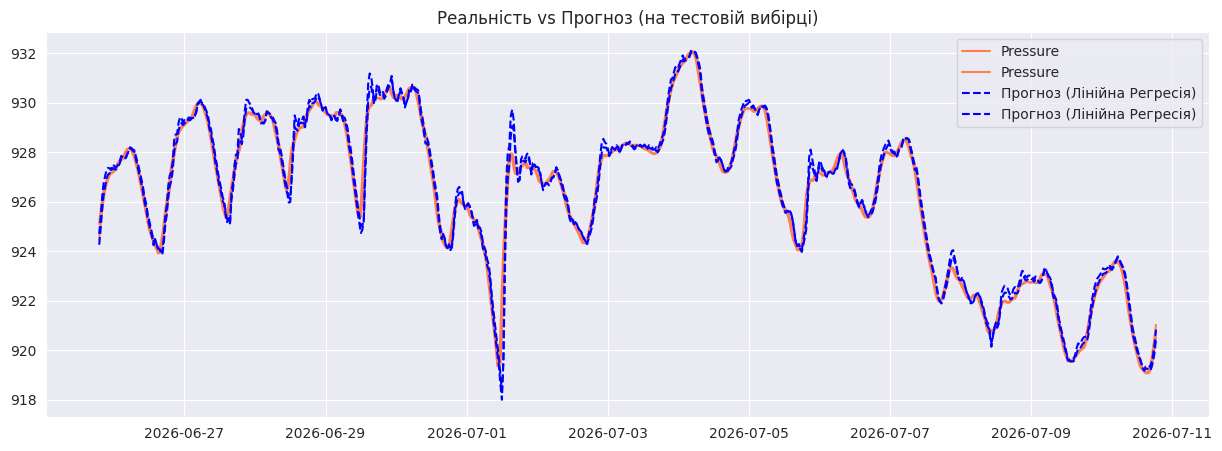

In [189]:
model_press = train_function(y_press, "Pressure")

--- Результати для Gas ---
MAE (+30 хв): 0.1604
MAE (+60 хв): 0.2405



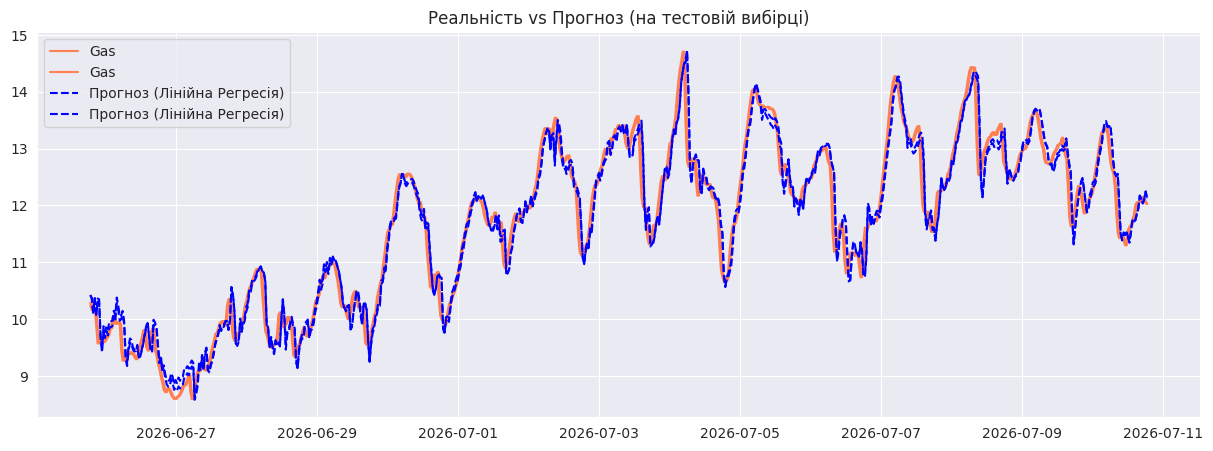

In [190]:
model_gas = train_function(y_gas, "Gas")

In [191]:
import joblib

joblib.dump(model_temp, '../src/model_temp.pkl')
joblib.dump(model_hum, '../src/model_hum.pkl')
joblib.dump(model_press, '../src/model_press.pkl')
joblib.dump(model_gas, '../src/model_gas.pkl')

print("✅ Всі 4 моделі успішно збережено!")

✅ Всі 4 моделі успішно збережено!
